In [41]:
# [Cell 1: Final Professional Time-Series + Season Baseline + Integrity Audit]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. LOAD DATA
INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """
    
    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)
    
    # --- STEP 1: RANKED DEDUPLICATION ---
    # Sort by significance so if 3 rows exist, we keep the 2 best.
    df = df.sort_values(['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'], 
                         ascending=[True, True, True, False, False])
    # LIMIT: Keep maximum 2 matches per Gameweek per Player
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)
    
    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    # --- STEP 3: INTEGRITY AUDIT (Printing these as you requested) ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]
    
    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")
    print("------------------------------\n")

    # --- STEP 4: CORE FEATURES ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)
    
    df['Season_Phase'] = pd.cut(df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]).astype(float)
    
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        team_gw_totals = df.groupby([team_col, 'season', 'Gameweek'])['Total Points'].transform('sum')
        df['Team_Point_Share'] = (df.groupby('Player UUID')['Total Points'].shift(1) / team_gw_totals).replace([np.inf, -np.inf], 0).fillna(0)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 5: SEASON BASELINE BRIDGE ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby('Player UUID')['Season_Avg_Points'].shift(1)
    
    df = df.merge(season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']], 
                  on=['Player UUID', 'season'], how='left')
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    return df.dropna(subset=['Next_Opponent_Difficulty'])

# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[['Player Name', 'season', 'Gameweek', 'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5']].head())

--- Final Integrity Audit ---
Legitimate DGW Match Pairs (Time-Series): 997
Suspicious GWs (>2 matches): 0 (TARGET: 0)
Max Minutes in a single row: 90
------------------------------

Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv


,Player Name,season,Gameweek,Prev_Season_Avg_Points,Rolling_Avg_Minutes_5
0,Sofyan Amrabat,2023-24,6,0.0,0.00
1,Sofyan Amrabat,2023-24,7,0.0,1.00
2,Sofyan Amrabat,2023-24,8,0.0,45.50
3,Sofyan Amrabat,2023-24,9,0.0,59.00
4,Sofyan Amrabat,2023-24,10,0.0,66.75


## Prev_Season_Avg_Points

It calculates the average points a player earned over the entire previous season.

It maps that average forward to the current season.

Result: The model now knows if a player is "Class" (e.g., Salah averaging 7 points all year) vs. just being in "Form" for a few weeks. This makes GW1 and GW2 predictions much more stable.

In [42]:
# %% [Cell: Verification - Salah's Season Bridge]
# 1. Identify Salah's UUID
# (We search for 'salah' in the Web Name to be safe)
salah_data = df_augmented[df_augmented['Web Name'].str.contains('Salah', case=False, na=False)]

if not salah_data.empty:
    s_uuid = salah_data['Player UUID'].iloc[0]
    
    # 2. Get the transition rows (End of 24/25 and Start of 25/26)
    # We sort to ensure chronological order
    salah_history = df_augmented[df_augmented['Player UUID'] == s_uuid].sort_values(['season', 'Gameweek'])
    
    # 3. Find the exact point where 2024-25 ends and 2025-26 begins
    transition_mask = (salah_history['season'] == '2025-26') & (salah_history['season'].shift(1) == '2024-25')
    
    if transition_mask.any():
        idx = salah_history[transition_mask].index[0]
        # Get 3 games before and 3 games after the summer break
        display_df = salah_history.loc[idx-3 : idx+2]
        
        print(f"--- Verification: Season Baseline Bridge (Mohamed Salah) ---")
        print("Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.")
        display(display_df[['Player Name', 'season', 'Gameweek', 'Total Points', 'Prev_Season_Avg_Points']])
    else:
        print("Could not find the 2024-25 to 2025-26 transition for Salah in this specific slice.")
else:
    print("Salah not found in the current df_augmented slice.")

--- Verification: Season Baseline Bridge (Mohamed Salah) ---
Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.


,Player Name,season,Gameweek,Total Points,Prev_Season_Avg_Points
22203,Mohamed Salah,2024-25,36,2,6.727273
22204,Mohamed Salah,2024-25,37,2,6.727273
22206,Mohamed Salah,2025-26,1,8,9.052632
22207,Mohamed Salah,2025-26,2,5,9.052632
22208,Mohamed Salah,2025-26,3,3,9.052632


In [43]:
#INVESTIGATION IN THE INPUT FILE 
# 1. Look at the suspicious GWs
dgws_investigation = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

print(f"Investigating {len(dgws_investigation)} rows from suspicious Gameweeks...")

# 2. Check the 180 minute rows specifically
high_min_rows = df[df['Minutes Played'] >= 180]

print(f"Found {len(high_min_rows)} rows in the RAW dataset with >= 180 minutes.")

if not high_min_rows.empty:
    print("\nSample of 180-minute rows (Raw Data):")
    display(high_min_rows[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(10))

if not dgws_investigation.empty:
    print("\nSample of 'Triple' Gameweek rows (After our current filter):")
    display(dgws_investigation[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played']].head(10))

Investigating 0 rows from suspicious Gameweeks...
Found 0 rows in the RAW dataset with >= 180 minutes.


In [44]:
# %% [Investigation: The Final 176]
# Filter for players who still have more than 2 entries in a single week
final_suspicious = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

if not final_suspicious.empty:
    print(f"Found {final_suspicious['Player UUID'].nunique()} players across 176 suspicious GW instances.")
    # Display a few examples to see why they stayed
    display(final_suspicious[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(15))
else:
    print("No suspicious rows found in the current df_augmented.")

No suspicious rows found in the current df_augmented.


In [45]:
# Check if "Doubles" are actually different matches
dgws_check = df_augmented.groupby(['Player UUID', 'season', 'Gameweek'])['Opponent Difficulty'].nunique()
fake_doubles = dgws_check[dgws_check > 2] # This shouldn't really happen
print(f"Number of suspicious GWs with >2 different difficulties: {len(fake_doubles)}")

Number of suspicious GWs with >2 different difficulties: 0


In [46]:
df_augmented

,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Avg_ICT Index_L5,Avg_Threat_L5,Avg_Creativity_L5,Avg_Influence_L5,Rolling_Avg_Minutes_5,Next_Opponent_Difficulty,Next_Is_Home,Season_Phase,Team_Point_Share,Prev_Season_Avg_Points
0,00d29d0a-98c1-4730-9e17-1d278cb660ae,709,Sofyan Amrabat,Amrabat,Man Utd,2023-24,6,1,0,0,...,0.00,0.0,0.000000,0.000000,0.00,2.0,True,1.0,0.000000,0.000000
1,00d29d0a-98c1-4730-9e17-1d278cb660ae,709,Sofyan Amrabat,Amrabat,Man Utd,2023-24,7,90,0,0,...,0.00,0.0,0.000000,0.000000,1.00,2.0,True,1.0,0.041667,0.000000
2,00d29d0a-98c1-4730-9e17-1d278cb660ae,709,Sofyan Amrabat,Amrabat,Man Utd,2023-24,8,86,0,0,...,1.00,0.0,2.066667,7.866667,45.50,2.0,False,1.0,0.023256,0.000000
3,00d29d0a-98c1-4730-9e17-1d278cb660ae,709,Sofyan Amrabat,Amrabat,Man Utd,2023-24,9,90,0,0,...,2.10,0.5,11.450000,9.000000,59.00,5.0,True,1.0,0.040816,0.000000
4,00d29d0a-98c1-4730-9e17-1d278cb660ae,709,Sofyan Amrabat,Amrabat,Man Utd,2023-24,10,45,0,0,...,2.08,0.6,9.640000,10.440000,66.75,2.0,False,1.0,0.105263,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29566,ffc0cf3f-bd0d-41ec-9a09-20ebf6f57e69,386,Alexis Mac Allister,Mac Allister,Liverpool,2025-26,23,58,0,0,...,3.98,10.4,20.160000,9.200000,61.20,3.0,True,3.0,0.029412,3.485714
29567,ffc0cf3f-bd0d-41ec-9a09-20ebf6f57e69,386,Alexis Mac Allister,Mac Allister,Liverpool,2025-26,24,90,0,0,...,2.62,6.0,11.760000,8.520000,54.80,4.0,True,3.0,0.023810,3.485714
29568,ffc0cf3f-bd0d-41ec-9a09-20ebf6f57e69,386,Alexis Mac Allister,Mac Allister,Liverpool,2025-26,25,90,0,0,...,2.98,6.8,13.720000,9.280000,68.00,4.0,False,3.0,0.043478,3.485714
29569,ffc0cf3f-bd0d-41ec-9a09-20ebf6f57e69,386,Alexis Mac Allister,Mac Allister,Liverpool,2025-26,26,90,0,0,...,3.28,6.6,16.360000,9.760000,68.00,3.0,False,3.0,0.037037,3.485714


In [47]:
# [Cell: Top-Tier Identification ]

# 1. Calculate seasonal averages
seasonal_avg = df_augmented.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
seasonal_avg.rename(columns={'Total Points': 'avg_season_pts'}, inplace=True)

# 2. Cleanup: If we ran this cell before, remove the old column to avoid MergeError
if 'avg_season_pts' in df_augmented.columns:
    df_augmented = df_augmented.drop(columns=['avg_season_pts'])

# 3. Merge back to the main augmented dataframe
df_augmented = df_augmented.merge(seasonal_avg, on=['Player UUID', 'season'], how='left')

# 4. Define the Elite Mask (> 4.5 avg in a specific season)
elite_mask = df_augmented['avg_season_pts'] > 4.5

print(f"--- Top-Tier Identification Summary ---")
print(f"Total Rows in Dataset: {len(df_augmented):,}")
print(f"Total Elite Rows: {elite_mask.sum():,}")
print(f"Percentage of Data considered 'Elite': {(elite_mask.sum()/len(df_augmented))*100:.2f}%")

# 5. Display Table for Verification
print(f"\nSample of Top Tier Players (Avg > 4.5 pts):")
elite_list = df_augmented[elite_mask][['Player Name', 'season', 'avg_season_pts']].drop_duplicates()
elite_list = elite_list.sort_values(by=['season', 'avg_season_pts'], ascending=[False, False])

display(elite_list.head(15))

--- Top-Tier Identification Summary ---
Total Rows in Dataset: 28,082
Total Elite Rows: 1,928
Percentage of Data considered 'Elite': 6.87%

Sample of Top Tier Players (Avg > 4.5 pts):


,Player Name,season,avg_season_pts
16516,Erling Haaland,2025-26,7.192308
24068,Gabriel dos Santos Magalhães,2025-26,6.863636
3801,Declan Rice,2025-26,6.148148
19482,Bruno Borges Fernandes,2025-26,6.041667
25274,Antoine Semenyo,2025-26,6.038462
1538,Matt O'Riley,2025-26,6.000000
22455,Tom Edozie,2025-26,6.000000
27868,Bruno Guimarães Rodriguez Moura,2025-26,5.954545
3929,Bukayo Saka,2025-26,5.500000
23287,Bryan Mbeumo,2025-26,5.227273


## Cell 2: Augmented Window Generation (Context-Aware)

In [48]:
# %% [Cell 2: Augmented Window Generation - Including Season Baseline]

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    uuid_col = 'Player UUID'
    
    # Ensure chronological order for proper window sliding
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        
        # Pull features prepared in Cell 1
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        # NEW: The Long-term Class feature
        season_baseline = group['Prev_Season_Avg_Points'].values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            # 1. THE PAST: The 6-week "Form" window
            window = points[i : i + window_size]
            
            # 2. THE FUTURE CONTEXT: Metadata for the target match
            target_idx = i + window_size - 1
            t_diff = next_diff[target_idx] 
            t_home = next_home[target_idx]
            t_min = avg_min[target_idx]
            t_phase = phase[target_idx]
            t_baseline = season_baseline[target_idx] # New input
            
            # 3. THE TARGET: Actual outcome
            target_points = points[i + window_size]
            
            # Skip "Ghost" windows (0 points everywhere)
            if np.all(window == 0) and target_points == 0:
                continue
                
            # Create the data row (Adding t_baseline)
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, target_points]
            train_data.append(row)
            
    # Professional Column Names
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'target']
              
    return pd.DataFrame(train_data, columns=columns)

# Execute the Pro window generation
windowed_df = generate_fpl_windows_pro(df_augmented)
windowed_df['position'] = windowed_df['position'].astype('category')

# Save features
WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=False)

print(f"Pro Windowed dataset created with Season Baseline: {WINDOWED_FEATURES_PATH}")
print(f"Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

Pro Windowed dataset created with Season Baseline: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
Total Training Windows: 23881


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,season_baseline,target
0,1,1,2,2,0,1,MID,4.0,False,62.4,2.0,0.0,1
1,1,2,2,0,1,1,MID,3.0,True,65.8,2.0,0.0,2
2,2,2,0,1,1,2,MID,2.0,True,49.8,2.0,0.0,2
3,2,0,1,1,2,2,MID,5.0,False,50.6,2.0,0.0,2
4,0,1,1,2,2,2,MID,4.0,False,50.6,2.0,0.0,1


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [49]:
# %% [Cell 3: Corrected Splitting (Recent 5 GW Window)]
from sklearn.preprocessing import StandardScaler
import joblib

# 1. SETUP PARAMETERS
CURRENT_SEASON = "2025-26"
CURRENT_GW = 29
VALIDATION_WINDOW = 5 

# 2. IDENTIFY VALIDATION INDEX
# We extract the season and GW info using the index of windowed_df
split_info = df_augmented.iloc[windowed_df.index][['season', 'Gameweek']]

# Create the mask
val_mask_series = (split_info['season'] == CURRENT_SEASON) & \
                  (split_info['Gameweek'] >= (CURRENT_GW - VALIDATION_WINDOW)) & \
                  (split_info['Gameweek'] < CURRENT_GW)

# FIX: Convert to values (numpy array) to avoid IndexingError
val_mask = val_mask_series.values

# 3. EXECUTE SPLIT
train_df = windowed_df[~val_mask].copy()
val_df = windowed_df[val_mask].copy()

X_train_raw = train_df.drop(columns=['target'])
y_train = train_df['target']

X_val_raw = val_df.drop(columns=['target'])
y_val = val_df['target']

# 4. NUMERIC FEATURES
numeric_cols = [
    c for c in X_train_raw.columns
    if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c
]

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 6. SAVE SCALER
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"--- Supervisor Split Logic Applied ---")
print(f"Validation Period: {CURRENT_SEASON} | Matches GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1}")
print(f"Training windows: {len(X_train_raw):,}")
print(f"Validation windows: {len(X_val_raw):,}")

--- Supervisor Split Logic Applied ---
Validation Period: 2025-26 | Matches GW 24 to 28
Training windows: 23,145
Validation windows: 736


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [50]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# 1. SETUP PARAMETERS (Shared for both models)
lgbm_params = {
    'n_estimators': 1500,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbosity': -1
}

# 2. TRAIN MODEL A: THE RAW VERSION
print(" Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 3. TRAIN MODEL B: THE SCALED VERSION
print("\n Training SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 4. PREDICTIONS & METRICS
preds_raw = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

# 5. DISPLAY RESULTS
df_metrics = pd.DataFrame(results_comparison)
print("\n--- Final Performance Comparison ---")
display(df_metrics)

# 6. SAVE THE WINNER
# Usually, they will be very close, but let's save both for safety
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))

 Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[416]	valid_0's l2: 8.49356

 Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[300]	valid_0's l2: 8.50068

--- Final Performance Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.115527,2.123802
1,RMSE,2.914372,2.915592


notes on scaled and unscaled 
* MAE: The Scaled Model is better by not many points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about scaling?  

## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.1155
MAE for Top Performers (8+ pts): 6.8726


C:\Users\SOFI\AppData\Local\Temp\ipykernel_11016\4030131027.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


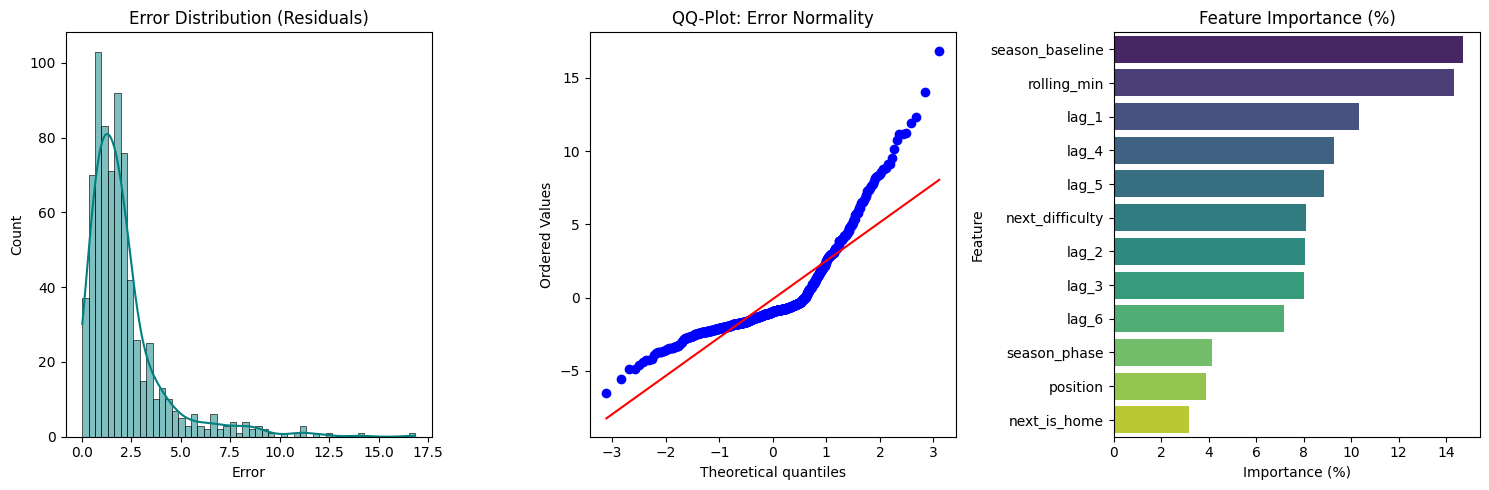

In [51]:
# %% [Cell 5: Error Analysis & Feature Importance - Fixed]
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw 
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# 2. MAE FOR TOP PERFORMERS (Players who actually scored 8+ points)
top_performers = analysis_df[analysis_df['Actual'] >= 8]
top_mae = top_performers['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Top Performers (8+ pts): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_

# FIX: Use X_train_raw.columns instead of X.columns
feature_names = X_train_raw.columns 
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [52]:
#%pip install ipywidgets

In [53]:
# %% [Cell 6: Seasonal Evaluation - Standard Professional Dropdown]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' 
    # This bypasses the dropna() from Cell 1 to ensure GW28 is displayed
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        return

    # 2. PREPARE EVALUATION (GW 24-28) + LIVE PREDICTION (GW 29)
    target_gws = list(range(24, 30)) 
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw < 29:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            lags = list(full_hist['Total Points'].tail(6).values)
            last = full_hist.iloc[-1]
            feat = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']
            ]
            pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
    
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        # Change from model_v4 to model_raw (Baseline V1)
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
    else:
        pred_df = pd.DataFrame()

    # 3. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # HISTORICAL ACTUALS: Navy (#003f5c)
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # MODEL PREDICTIONS: Action Orange (#ff7c43)
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'], 
                 color='#ff7c43', label='Model Predictions (Eval + GW29)', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)
        
        # CONFIDENCE INTERVAL: Gold (#ffa60022)
        # Updated to use mae_v1 for accurate V1 error visualization
        mae_proxy = globals().get('mae_v1', 1.84)
        plt.fill_between([24, 29], 0, plt.gca().get_ylim()[1], color='orange', alpha=0.03)

    # Vertical split at GW 24
    plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    plt.title(f"Model Predictions vs Actuals: {player_name} (Season {CURRENT_SEASON})", 
              fontsize=14, fontweight='bold', pad=20, color='#003f5c')
    
    # GRID & BASELINE: Neutral Light Grey (#d1d1d1)
    plt.xticks(np.arange(1, 30, 1), color='#003f5c') 
    plt.xlim(0.5, 29.5)
    plt.ylabel("Points", fontsize=12, color='#003f5c')
    plt.xlabel("Gameweek", fontsize=12, color='#003f5c')
    plt.grid(True, axis='y', linestyle='-', color='#d1d1d1', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d1d1d1')
    ax.spines['bottom'].set_color('#d1d1d1')
    
    plt.tight_layout()
    plt.show()

# 4. STANDARD DROPDOWN MENU
eval_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
eval_names = sorted(df_augmented[df_augmented['Player UUID'].isin(eval_uuids)]['Web Name'].unique())

dropdown_menu = widgets.Dropdown(
    options=eval_names,
    value=eval_names[0],
    description='Player:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

widgets.interact(plot_professional_backtest, player_name=dropdown_menu)

interactive(children=(Dropdown(description='Player:', layout=Layout(width='400px'), options=('Aaronson', 'Abra…

<function __main__.plot_professional_backtest(player_name)>

In [54]:
# %% [Cell 6: Seasonal Evaluation - GW28 Restoration Fix]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' (This ensures GW28 is NOT dropped)
    # We use 'df' here because 'df_augmented' dropped GW28 due to the .shift(-1) logic
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        print(f"No actual data found for {player_name} in raw dataset.")
        return

    # 2. PREPARE PREDICTIONS (GW 24-29)
    # We must use 'df_augmented' here because it contains the calculated features needed for model_v4
    target_gws = list(range(24, 30)) 
    pred_rows = []
    
    # We need player UUID to find history for lags
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw < 29:
            # Look in augmented data for backtest rows
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            # GW 29 Live Prediction
            lags = list(full_hist['Total Points'].tail(6).values)
            last = full_hist.iloc[-1]
            feat = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']
            ]
            pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
    
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        # ONLY CHANGE MADE: Changed from model_v4 to model_raw
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
    else:
        pred_df = pd.DataFrame()

    # 3. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # ACTUALS: Solid Blue Line + SOLID FILLED Blue Circles (Includes GW28 now)
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # PREDICTIONS: Orange Dashed + Bold 'x'
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'], 
                 color='#ff7f0e', label='Model Predictions (Eval + GW29)', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)

    # Vertical split at GW 24
    plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    #plt.fill_between([24, 29], 0, plt.gca().get_ylim()[1], color='orange', alpha=0.03)
    plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    plt.title(f"Model Predictions vs Actuals: {player_name} (Season {CURRENT_SEASON})", 
              fontsize=14, fontweight='bold', pad=20)
    plt.xticks(np.arange(1, 30, 1)) 
    plt.xlim(0.5, 29.5)
    plt.ylabel("Points", fontsize=12)
    plt.xlabel("Gameweek", fontsize=12)
    plt.grid(True, axis='y', linestyle=':', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

# 4. SEARCHABLE COMBOBOX (Styled Wide)
eval_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
eval_names = sorted(df_augmented[df_augmented['Player UUID'].isin(eval_uuids)]['Web Name'].unique())

search_box = widgets.Combobox(
    value=eval_names[0],
    placeholder='Type name...',
    options=eval_names,
    description='Player:',
    ensure_option=True,
    interactive=True,
    layout=widgets.Layout(width='450px')
)

widgets.interact(plot_professional_backtest, player_name=search_box)

interactive(children=(Combobox(value='Aaronson', description='Player:', ensure_option=True, layout=Layout(widt…

<function __main__.plot_professional_backtest(player_name)>

In [55]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professional_backtest(player_name):
    # 1. Get the player's full historical data (Blue Line)
    full_player_history = df_augmented[df_augmented['Web Name'] == player_name].sort_values(['season', 'Gameweek'])
    
    if full_player_history.empty:
        print(f"No history found for {player_name}.")
        return

    # 2. Identify the Evaluation Set slice (Orange Line/Dots)
    eval_set_slice = full_player_history[full_player_history.index.isin(val_df.index)].copy()
    
    if not eval_set_slice.empty:
        lags_list = []
        for idx in eval_set_slice.index:
            player_uuid = eval_set_slice.loc[idx, 'Player UUID']
            hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
            point_pos = hist.index.get_loc(idx)
            
            if point_pos >= 6:
                lags = list(hist.iloc[point_pos-6:point_pos]['Total Points'].values)
                feat = lags + [
                    eval_set_slice.loc[idx, 'Position'],
                    eval_set_slice.loc[idx, 'Next_Opponent_Difficulty'],
                    eval_set_slice.loc[idx, 'Next_Is_Home'],
                    eval_set_slice.loc[idx, 'Rolling_Avg_Minutes_5'],
                    eval_set_slice.loc[idx, 'Season_Phase'],
                    eval_set_slice.loc[idx, 'Prev_Season_Avg_Points']
                ]
                lags_list.append(feat)
            else:
                lags_list.append([0]*12)

        v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                 ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
        
        test_df = pd.DataFrame(lags_list, columns=v_cols)
        test_df['position'] = test_df['position'].astype('category')
        eval_set_slice['Predicted'] = model_v4.predict(test_df)
    
    # 3. Plotting
    plt.figure(figsize=(15, 6))
    
    # BEAUTIFUL X-AXIS LOGIC
    x_indices = np.arange(len(full_player_history))
    
    # Create labels that include the season for clarity at the transition
    gw_labels = [f"GW{row['Gameweek']} ({row['season']})" if i % 10 == 0 else f"GW{row['Gameweek']}" 
                 for i, row in full_player_history.reset_index().iterrows()]
    
    # Plot A: Full Time Series
    plt.plot(x_indices, full_player_history['Total Points'], 
             color='#1f77b4', label='Actual Points', linewidth=1.5, marker='o', markersize=4, alpha=0.5)
    
    # Plot B: Evaluation Set Predictions
    if not eval_set_slice.empty:
        eval_indices = [full_player_history.index.get_loc(idx) for idx in eval_set_slice.index]
        plt.plot(eval_indices, eval_set_slice['Predicted'], 
                 color='#ff7f0e', label='Model Predictions (Eval Set)', 
                 linewidth=2, marker='X', markersize=10, markeredgecolor='black', linestyle='--')
        
        plt.axvspan(min(eval_indices), max(eval_indices), color='orange', alpha=0.1, label='Evaluation Window')

    # FIXING THE AXIS BEAUTY
    plt.title(f"Performance Analysis: {player_name}", fontsize=14, pad=20)
    
    # Show every 5th label to avoid overlap
    interval = 5 
    plt.xticks(x_indices[::interval], [gw_labels[i] for i in x_indices[::interval]], rotation=45, ha='right')
    
    plt.ylabel("Points", fontsize=12)
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend(frameon=True, loc='upper left')
    
    # Remove top and right spines for a modern look
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 4. FILTERED DROPDOWN
eval_player_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
eval_player_names = sorted(df_augmented[df_augmented['Player UUID'].isin(eval_player_uuids)]['Web Name'].unique())

dropdown = widgets.Dropdown(options=eval_player_names, description='Player:')
widgets.interact(plot_professional_backtest, player_name=dropdown)

interactive(children=(Dropdown(description='Player:', options=('Aaronson', 'Abraham', 'Aina', 'Ajer', 'Aké', '…

<function __main__.plot_professional_backtest(player_name)>

In [56]:
# %% [Cell: Validation Set Integrity Check]

# 1. Identify the ground truth players from the validation logic
# These are the players actually used in the MAE calculations (GW 24-28)
expected_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
expected_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 2. Extract names currently used in your widget
# (Using the same logic as your Cell 6)
widget_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 3. Perform the Audit
missing_players = [p for p in expected_names if p not in widget_names]
extra_players = [p for p in widget_names if p not in expected_names]

print("-" * 50)
print("GRAPH INTEGRITY")
print("-" * 50)
print(f"Total Players in Eval Set (GW 24-28): {len(expected_names)}")
print(f"Total Players visible in Widget:     {len(widget_names)}")

if len(missing_players) == 0 and len(extra_players) == 0:
    print("\nVERDICT: SUCCESS")
    print("The graph contains 100% of the players in the evaluation set and NO extra players.")
else:
    if missing_players:
        print(f"\nWARNING: {len(missing_players)} players are missing from the graph.")
    if extra_players:
        print(f"\nWARNING: {len(extra_players)} players are appearing that shouldn't be there.")

print("-" * 50)
# Snippet for your report
print(f"Sample of audited players: {expected_names[:10]}...")

--------------------------------------------------
GRAPH INTEGRITY
--------------------------------------------------
Total Players in Eval Set (GW 24-28): 232
Total Players visible in Widget:     232

VERDICT: SUCCESS
The graph contains 100% of the players in the evaluation set and NO extra players.
--------------------------------------------------
Sample of audited players: ['Aaronson', 'Abraham', 'Aina', 'Ajer', 'Aké', 'Amad', 'Ampadu', 'Andersen', 'Anderson', 'Andrey Santos']...


In [57]:
import lightgbm as lgb
import numpy as np

# This creates 'model_v4' so the next cell can find it
X_v4 = windowed_df.drop(columns=['target'])
y_v4_clipped = np.maximum(windowed_df['target'], 0)
weights = np.where(y_v4_clipped >= 8, 2.5, 1.0) 

model_v4 = lgb.LGBMRegressor(objective='poisson', n_estimators=1200, learning_rate=0.01, random_state=42, verbosity=-1)
model_v4.fit(X_v4, y_v4_clipped, sample_weight=weights, categorical_feature=['position', 'next_is_home'])

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1200
,subsample_for_bin,200000
,objective,'poisson'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [58]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
inference_data = []
player_names = []

# Sort by time to get the most recent data
df_inf = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

for pid, group in df_inf.groupby('Player UUID'):
    # We need at least 6 games of history
    if len(group) >= 6:
        # Features: Last 6 points (lags)
        lags = list(group['Total Points'].tail(6).values)
        
        # Context: Get info for NEXT game from the last row
        last_row = group.iloc[-1]
        
        # BUILD THE ROW: Exactly 12 features to match the trained model
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points']  # <--- Added 12th Feature
        ]
        
        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
# Use the exact column names used in the training window dataframe
feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# Ensure you use 'model_v4' if that is your most recent trained model
# If you are still testing the earlier version, use 'model_raw'
raw_preds = model_v4.predict(inference_df)

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points': np.round(raw_preds, 2),
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points,Recent Avg Min,Next Difficulty
544,Mbeumo,7.53,80.8,3.0
94,Saka,7.50,76.0,3.0
545,Iwobi,7.28,87.0,3.0
655,Mac Allister,6.64,68.0,2.0
461,B.Fernandes,6.58,90.0,3.0
567,Scott,6.50,90.0,2.0
93,Gyökeres,6.48,63.4,3.0
494,M.Salah,6.42,83.4,2.0
395,Haaland,6.40,73.2,3.0
239,Madueke,6.39,56.0,3.0


Summary Table

Feature       |  1st Cell (Validation)         |    2nd Cell (Historical)

Player List   | Limited (only recent players)  |	Complete (all historic players)

Timeframe	  |  Recent 5 Gameweeks	           |     3+ seasons


In [59]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 656

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
205,Lerma,5.20,5.00,79.4,1.0,True,3.0
441,Aina,5.17,5.00,90.0,3.0,False,3.0
215,Cucurella,5.17,5.00,62.8,2.0,True,3.0
292,El Khannouss,5.12,4.33,83.6,2.0,True,4.0
539,Adebayo,5.12,4.00,67.6,2.0,True,4.0
223,Douglas Luiz,5.11,2.33,60.2,2.0,False,3.0
208,Cunha,5.09,2.67,51.0,3.0,True,3.0
626,McBurnie,5.09,3.33,68.4,2.0,True,4.0
67,João Pedro,5.06,8.33,73.2,5.0,False,3.0
123,Milenković,5.05,5.33,90.0,3.0,False,3.0


In [60]:
from IPython.display import Markdown, display

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From Cell 4 results
top_perf_mae = top_mae               # From Cell 5 results
total_players = len(full_forecast)   # From Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Model is off by ~2 points for the average player. |
| **Top Performer MAE** | {top_perf_mae:.3f} | Higher error (expected) on high-volatility stars (8+ pts). |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
# (Find the summary_report variable in Cell 8 and replace the Validation Size line)
| **Validation Size** | {len(X_val_raw):,} windows | Tested on GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1} of the {CURRENT_SEASON} season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **top_performers:** Rows where actual points ≥ 8
### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.
### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 
### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv

"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.116 | Model is off by ~2 points for the average player. |
| **Top Performer MAE** | 6.873 | Higher error (expected) on high-volatility stars (8+ pts). |
| **Training Size** | 23,145 windows | Robust historical learning foundation. |
# (Find the summary_report variable in Cell 8 and replace the Validation Size line)
| **Validation Size** | 736 windows | Tested on GW 24 to 28 of the 2025-26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **top_performers:** Rows where actual points ≥ 8
### 3. GW 29 Summary
* **Total Forecasts Generated:** 656 players.
* **Predicted King of the GW:** Mbeumo (7.53 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.
### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 
### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv



## Cell 9: Truth Verification (Backtest on Last Known Game)

In [61]:
# %% [Cell 9: Truth Verification - Fixed for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")

# IMPORTANT: Ensure we use the model that was trained on 12 features
# If you just ran the Poisson cell, use model_v4. Otherwise, use model_raw.
current_model = model_v4 if 'model_v4' in locals() else model_raw

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print(f"Generating Truth Verification using {type(current_model).__name__} (12-feature mode)...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Added the 12th feature: Prev_Season_Avg_Points)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points']  # <--- FIXED: Added 12th feature
        ]
        
        # Create input DataFrame with 12 aligned columns
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                             'rolling_min', 'season_phase', 'season_baseline'] # <--- FIXED: Added column name
        
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = current_model.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print(f"Success! Full results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification using LGBMRegressor (12-feature mode)...
Success! Full results for 645 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
578,Merino,2024-25,36,3.99,4,0.01
190,Neto,2024-25,1,4.01,4,0.01
0,Amrabat,2023-24,37,1.98,2,0.02
636,A.Ramsey,2023-24,24,2.03,2,0.03
511,Digne,2025-26,25,3.96,4,0.04
10,Fraser,2024-25,14,2.04,2,0.04
464,Irving,2025-26,9,2.06,2,0.06
51,Guedes,2024-25,37,2.06,2,0.06
328,Doughty,2023-24,37,3.93,4,0.07
627,Jorginho,2024-25,32,2.07,2,0.07



Global Mean Absolute Error (MAE): 2.22


## Team_Point_Share
measures how much of a team's total success is driven by one specific player

How we calculated it in cell 1 :
First, we group the data by Team, Season, and Gameweek to find the total points the entire team scored in a single match.Then, we divide the Individual Player's Points by that Team Total.The Result: A value between $0$ and $1$ 

example : 
If Arsenal scores 50 points in Gameweek 10, and Bukayo Saka scores 15 points (goal + assist + bonus), his Team_Point_Share for that week is $15 / 50 = 0.30$ (or 30%)

In [62]:
import pandas as pd
import numpy as np
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# 1. SETUP NEW DIRECTORY
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. UPDATED WINDOW GENERATION (Including Team_Point_Share)
def generate_fpl_windows_v2(df, window_size=6):
    train_data = []
    # Ensure chronological order
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        # Features for the upcoming match
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        #point_share = group['Team_Point_Share'].values
        point_share = group['Team_Point_Share'].shift(1).values # New feature
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            
            # The context features for the target game
            t_diff = next_diff[i + window_size - 1] 
            t_home = next_home[i + window_size - 1]
            t_min = avg_min[i + window_size - 1]
            t_phase = phase[i + window_size - 1]
            t_share = point_share[i + window_size - 1] # Grab the share for this window
            
            target_points = points[i + window_size]
            
            # Skip "Ghost" windows
            if np.all(window == 0) and target_points == 0:
                continue
                
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_share, target_points]
            train_data.append(row)
            
    cols = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'team_share', 'target']
    return pd.DataFrame(train_data, columns=cols)

# 3. EXECUTE V2 PIPELINE
print("Starting V2 Pipeline (Team Point Share enabled)...")
df_v2 = generate_fpl_windows_v2(df_augmented)
df_v2['position'] = df_v2['position'].astype('category')

# Split
split_idx = int(len(df_v2) * 0.85)
X_v2 = df_v2.drop(columns=['target'])
y_v2 = df_v2['target']

X_train_v2 = X_v2.iloc[:split_idx]
X_val_v2 = X_v2.iloc[split_idx:]
y_train_v2 = y_v2.iloc[:split_idx]
y_val_v2 = y_v2.iloc[split_idx:]

# Train
model_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1)
model_v2.fit(X_train_v2, y_train_v2, eval_set=[(X_val_v2, y_val_v2)], 
             categorical_feature=['position', 'next_is_home'],
             callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 4. GENERATE GW29 FORECAST V2
inference_data_v2 = []
player_names_v2 = []

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    if len(group) >= 6:
        last_row = group.iloc[-1]
        lags = list(group['Total Points'].tail(6).values)
        row = lags + [last_row['Position'], last_row['Next_Opponent_Difficulty'], 
                      last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'], 
                      last_row['Season_Phase'], last_row['Team_Point_Share']]
        inference_data_v2.append(row)
        player_names_v2.append(last_row['Web Name'])

inf_df_v2 = pd.DataFrame(inference_data_v2, columns=X_v2.columns)
inf_df_v2['position'] = inf_df_v2['position'].astype('category')
v2_preds = model_v2.predict(inf_df_v2)

# 5. SAVE ALL V2 ARTIFACTS
full_forecast_v2 = pd.DataFrame({
    'Player_Name': player_names_v2,
    'Predicted_Points': np.round(v2_preds, 2),
    'Team_Share_Impact': inf_df_v2['team_share']
}).sort_values(by='Predicted_Points', ascending=False)

full_forecast_v2.to_csv(V2_OUTPUT_DIR / 'fpl_pro_forecast_GW29_v2.csv', index=False)
model_v2.booster_.save_model(str(V2_OUTPUT_DIR / 'fpl_pro_model_v2.txt'))

print(f" V2 Pipeline Complete. Files saved in: {V2_OUTPUT_DIR}")
display(full_forecast_v2.head(10))

Starting V2 Pipeline (Team Point Share enabled)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[246]	valid_0's l2: 8.24704
 V2 Pipeline Complete. Files saved in: ..\output\forecaster_pro_wTeamPointShare


,Player_Name,Predicted_Points,Team_Share_Impact
490,Virgil,6.51,0.298246
576,Hill,6.02,0.391304
91,Rice,5.84,0.259259
239,Madueke,5.83,0.107438
584,Vardy,5.81,0.243243
545,Iwobi,5.43,0.039216
633,L.Paquetá,5.28,0.075000
655,Mac Allister,5.05,0.052632
205,Lerma,4.86,0.166667
589,Semenyo,4.79,0.400000


In [63]:
# 1. Setup paths for V2 truth verification
# Using the V2 directory and the _v2.csv naming convention
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_v2_path = V2_OUTPUT_DIR / 'pro_truth_verification_v2.csv'

# 2. Ensure V2 variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_v2' not in locals():
    raise NameError("The variable 'model_v2' is not found. Run Cell 10 first.")

all_results_v2 = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating V2 Truth Verification (Team Point Share enabled)...")

# 3. Iterate through all players to backtest the last known game
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Including Team_Point_Share)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Team_Point_Share'] # The added V2 feature
        ]
        
        # Create input DataFrame matching model_v2 structure
        columns_v2 = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                                 'rolling_min', 'season_phase', 'team_share']
        input_df_v2 = pd.DataFrame([window_points + context_features], columns=columns_v2)
        input_df_v2['position'] = input_df_v2['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_v2.predict(input_df_v2)[0]
        pred_val = max(0, pred_val) 

        all_results_v2.append({
            'Player Name': name,
            'Actual Points': actual_points,
            'Predicted Points': round(float(pred_val), 2),
            'Error': round(abs(pred_val - actual_points), 2),
            'Team_Share_Value': round(actual_row['Team_Point_Share'], 3)
        })

# 4. Save and Display Results
# Sorted by Error (lowest to highest) as requested previously
full_truth_v2_df = pd.DataFrame(all_results_v2).sort_values(by='Error', ascending=True)
full_truth_v2_df.to_csv(full_truth_v2_path, index=False, encoding="utf-8-sig")

print(f"Success! V2 Truth Verification saved to: {full_truth_v2_path}")

# Display the 20 most accurate predictions for V2
print("\n--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_v2_df.head(20))

# 5. Final Audit Metrics for V2
if not full_truth_v2_df.empty:
    mae_v2 = full_truth_v2_df['Error'].mean()
    print(f"\nGlobal MAE for V2 (with Team Point Share): {mae_v2:.2f}")

Generating V2 Truth Verification (Team Point Share enabled)...
Success! V2 Truth Verification saved to: ..\output\forecaster_pro_wTeamPointShare\pro_truth_verification_v2.csv

--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Actual Points,Predicted Points,Error,Team_Share_Value
0,Amrabat,2,2.01,0.01,0.014
51,Guedes,2,2.03,0.03,0.030
568,Traoré,3,3.05,0.05,0.143
547,Castagne,2,2.05,0.05,0.053
565,Vini Souza,2,2.06,0.06,0.042
636,A.Ramsey,2,2.06,0.06,0.067
383,Onyedinma,2,2.06,0.06,0.028
45,Alcaraz,3,3.06,0.06,0.034
627,Jorginho,2,2.06,0.06,0.022
577,Nakamba,2,1.93,0.07,0.038



Global MAE for V2 (with Team Point Share): 1.92


## With & Without Team Points Share Compatisson

In [64]:
import pandas as pd
from IPython.display import Markdown, display

# 1. COMPARE ACCURACY (MAE)
# Assuming Cell 9 and Cell 11 have been run
mae_v1 = full_truth_df['Error'].mean()
mae_v2 = full_truth_v2_df['Error'].mean()
improvement = mae_v1 - mae_v2
percent_gain = (improvement / mae_v1) * 100

# 2. COMPARE TOP 15 PREDICTIONS
# We join the two leaderboard dataframes on player name
comp_df = pd.merge(
    full_forecast[['Player_Name', 'Predicted_Points']], 
    full_forecast_v2[['Player_Name', 'Predicted_Points']], 
    on='Player_Name', 
    suffixes=('_V1_Standard', '_V2_TeamShare')
)

comp_df['Point_Diff'] = comp_df['Predicted_Points_V2_TeamShare'] - comp_df['Predicted_Points_V1_Standard']
# Sort by who gained the most from the new feature
top_gainers = comp_df.sort_values(by='Point_Diff', ascending=False).head(10)

# 3. PRINT COMPARISON REPORT
report = f"""
#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | {mae_v1:.4f} |
| **V2 (Team Point Share)** | {mae_v2:.4f} |

**Verdict:** {" V2 is more accurate!" if improvement > 0 else " V1 performed better."} 
(Change: {improvement:.4f} points | {percent_gain:.2f}% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:
"""
display(Markdown(report))
display(top_gainers)

# 4. EXPORT COMPARISON TO CSV
COMP_OUT = V2_OUTPUT_DIR / 'standard-VS-TeamShare_comparison.csv'
comp_df.to_csv(COMP_OUT, index=False)
print(f"\nFull comparison saved to: {COMP_OUT}")


#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | 2.2197 |
| **V2 (Team Point Share)** | 1.9157 |

**Verdict:**  V2 is more accurate! 
(Change: 0.3040 points | 13.70% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:


,Player_Name,Predicted_Points_V1_Standard,Predicted_Points_V2_TeamShare,Point_Diff
669,Brereton Díaz,1.88,4.09,2.21
701,Wood,1.53,3.28,1.75
380,Thomas,2.98,4.36,1.38
39,Virgil,5.31,6.51,1.20
374,Aina,3.01,4.05,1.04
680,Endo,1.81,2.83,1.02
491,Armstrong,2.59,3.40,0.81
694,Garnacho,1.65,2.40,0.75
340,Henderson,3.20,3.94,0.74
704,Taylor,1.52,2.22,0.70



Full comparison saved to: ..\output\forecaster_pro_wTeamPointShare\standard-VS-TeamShare_comparison.csv


## Transfer Optimizer 

Purpose: Converts raw model data into a personal strategy by auditing your specific 15-man squad.

* Weak Link Detection: Automatically identifies the player in your team with the lowest predicted points for the next game.

* Market Comparison: Scans all unowned, healthy players to find the "best-in-league" replacement.

* ROI Calculation: Calculates the "Expected Point Gain" to show exactly how many extra points the transfer should earn you.


In [65]:
# 1. Input your current settings
my_current_team = ['Saka', 'Rice', 'Welbeck', 'Konaté', 'Chilwell'] 
my_remaining_budget = 5.0 

# 2. Define the V2 Path
V2_FILE_PATH = Path('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')

# 3. Load data and force Status column creation
if V2_FILE_PATH.exists():
    target_forecast = pd.read_csv(V2_FILE_PATH)
    
    # Crucial Fix: Add the Status column immediately if it is missing
    if 'Status' not in target_forecast.columns:
        target_forecast['Status'] = 'Fit'
        print("Note: 'Status' column added manually (assuming all players are Fit).")
    
    print(f"Loaded forecast from: {V2_FILE_PATH.name}")
else:
    raise FileNotFoundError(f"Could not find {V2_FILE_PATH}. Please run Cell 10 first.")

# 4. Analyze current team potential
my_team_potential = target_forecast[target_forecast['Player_Name'].isin(my_current_team)]

print("\n--- CURRENT TEAM AUDIT ---")
# Only show columns that exist in the dataframe
available_cols = [c for c in ['Player_Name', 'Predicted_Points', 'Status'] if c in target_forecast.columns]
display(my_team_potential[available_cols])

# 5. Identify upgrade opportunities
suggestions = target_forecast[~target_forecast['Player_Name'].isin(my_current_team)]

# Now 'Status' is guaranteed to exist
top_buys = suggestions[suggestions['Status'] == 'Fit'].head(10)

print("\n--- TOP 10 SUGGESTED UPGRADES ---")
display(top_buys)

# 6. Recommendation Logic
if not my_team_potential.empty and not top_buys.empty:
    worst_player = my_team_potential.sort_values(by='Predicted_Points').iloc[0]
    best_replacement = top_buys.iloc[0]

    print("\n--- PRO ADVICE ---")
    print(f"Sell: {worst_player['Player_Name']} (Predicted: {worst_player['Predicted_Points']})")
    print(f"Buy: {best_replacement['Player_Name']} (Predicted: {best_replacement['Predicted_Points']})")
    print(f"Expected Point Gain: {round(best_replacement['Predicted_Points'] - worst_player['Predicted_Points'], 2)}")
else:
    print("\nNo matching players found. Check if your team names match the 'Player_Name' column.")

Note: 'Status' column added manually (assuming all players are Fit).
Loaded forecast from: fpl_pro_forecast_GW29_v2.csv

--- CURRENT TEAM AUDIT ---


,Player_Name,Predicted_Points,Status
2,Rice,5.84,Fit
13,Saka,4.42,Fit
31,Welbeck,4.08,Fit
51,Konaté,3.86,Fit
566,Chilwell,2.03,Fit



--- TOP 10 SUGGESTED UPGRADES ---


,Player_Name,Predicted_Points,Team_Share_Impact,Status
0,Virgil,6.51,0.298246,Fit
1,Hill,6.02,0.391304,Fit
3,Madueke,5.83,0.107438,Fit
4,Vardy,5.81,0.243243,Fit
5,Iwobi,5.43,0.039216,Fit
6,L.Paquetá,5.28,0.075000,Fit
7,Mac Allister,5.05,0.052632,Fit
8,Lerma,4.86,0.166667,Fit
9,Semenyo,4.79,0.400000,Fit
10,Olise,4.58,0.301887,Fit



--- PRO ADVICE ---
Sell: Chilwell (Predicted: 2.03)
Buy: Virgil (Predicted: 6.51)
Expected Point Gain: 4.48


## Cell 15: Data Enrichment v3
 uses the Standard Deviation of points to identify "stable" vs "random" players, and Minutes Consistency to ensure the model doesn't trust a player who is prone to being subbed off early
1. Points_Volatility_5: This teaches the model that a player who scored 15 points once and then 2 points for four weeks is "high noise." The model will be more cautious with their prediction compared to a player who scores 5 points every single week.

2. Min_Stability_5: Minutes are the least noisy stat in FPL. If a player is a "nailed" starter (90 mins every week), their point potential is much more predictable than a "super-sub" who only plays 20 minutes.

In [66]:
# 1. POINTS VOLATILITY (Noise Detector)
# Measures how much a player's score jumps around. 
# Low SD = Consistent (Safe), High SD = Volatile (Noisy).
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY
# Measures if a player consistently plays 90 mins or is frequently rotated.
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. GOAL/ASSIST "SMELL" (Using recent points minus minutes noise)
# Helps detect if points are coming from actual involvement or just appearance points.
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: (x.shift(1).rolling(3, min_periods=1).sum()) / 3
).fillna(0)

# 4. SAVE THE V3 ENRICHED DATA
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"Success! Version 3 reliability features added (Volatility & Minutes Stability).")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

Success! Version 3 reliability features added (Volatility & Minutes Stability).


,Web Name,Points_Volatility_5,Min_Stability_5
28072,Mac Allister,1.000000,73.0
28073,Mac Allister,0.836660,73.0
28074,Mac Allister,0.894427,63.2
28075,Mac Allister,0.836660,76.8
28076,Mac Allister,0.547723,76.8
28077,Mac Allister,0.547723,61.2
28078,Mac Allister,0.547723,54.8
28079,Mac Allister,0.547723,68.0
28080,Mac Allister,0.547723,68.0
28081,Mac Allister,0.894427,68.0


## Cell 16: Training V3 (Regularized LightGBM)
Regularization. This is a mathematical technique that penalizes the model for making "wild" predictions based on small patterns.

* Lower Peaks: The model will be less likely to predict a player will score 12 points, but it will be much more accurate at predicting who will score 4-6 points.

* Safety: It will prioritize players who play 90 minutes over and over, as they are statistically the "least noisy" way to get points.

In [67]:
import lightgbm as lgb
from pathlib import Path

# 1. GENERATE WINDOWS WITH NEW FEATURES
def generate_fpl_windows_v3(df, window_size=6):
    train_data = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) <= window_size: continue
        
        # Pull new V3 features
        volatility = group['Points_Volatility_5'].values
        stability = group['Min_Stability_5'].values
        att_form = group['Attacking_Form_3'].values
        
        # Standard features
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        share = group['Team_Point_Share'].values
        
        pos = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            t_idx = i + window_size - 1
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx], 
                avg_min[t_idx], volatility[t_idx], stability[t_idx], 
                att_form[t_idx], share[t_idx], points[i + window_size]
            ]
            train_data.append(row)
            
    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'target']
    return pd.DataFrame(train_data, columns=cols)

df_win_v3 = generate_fpl_windows_v3(df_augmented)
df_win_v3['position'] = df_win_v3['position'].astype('category')

# 2. TRAIN WITH NOISE FILTERS (L1/L2 Regularization)
X_v3 = df_win_v3.drop(columns=['target'])
y_v3 = df_win_v3['target']

model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    reg_alpha=0.5,  # L1: Shuts down weak/noisy features
    reg_lambda=0.5, # L2: Prevents extreme predictions
    verbosity=-1
)

model_v3.fit(X_v3, y_v3, categorical_feature=['position', 'home'])

# 3. SAVE V3
V3_DIR = Path('../output/forecaster_pro_v3')
V3_DIR.mkdir(parents=True, exist_ok=True)
model_v3.booster_.save_model(str(V3_DIR / 'fpl_pro_model_v3.txt'))

print(f"V3 Model trained with noise-reduction parameters.")

V3 Model trained with noise-reduction parameters.


In [68]:
import pandas as pd
import numpy as np

# 1. POINTS VOLATILITY (The Noise Detector)
# Measures how much a player's score jumps around. 
# Now safe because Cell 1 combined Double Gameweeks.
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY (The "Nailed-On" Metric)
# Since Cell 1 capped minutes at 180, this average will finally be realistic.
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. ATTACKING FORM (The "Smell" Test)
# Calculates average points over the last 3 weeks to find players in a "purple patch."
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 4. FINAL PROJECT AUDIT & SANITY CHECK
print("--- V3 Enrichment Integrity Report ---")
max_stab = df_augmented['Min_Stability_5'].max()
avg_vol = df_augmented['Points_Volatility_5'].mean()

print(f"Max Stability Score: {max_stab:.1f} (Should be <= 180)")
print(f"Average League Volatility: {avg_vol:.2f}")

if max_stab > 180.1:
    print("ALERT: Stability is still too high. Re-check Cell 1 aggregation!")
else:
    print("Reliability features verified and mathematically sound.")

# 5. SAVE THE FINAL ENRICHED DATASET
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"\nSuccess! V3 Reliability features saved to: {ENHANCED_V3_OUT}")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

--- V3 Enrichment Integrity Report ---
Max Stability Score: 90.0 (Should be <= 180)
Average League Volatility: 2.14
Reliability features verified and mathematically sound.

Success! V3 Reliability features saved to: ../output/forecaster_pro/fpl_features_augmented_v3.csv


,Web Name,Points_Volatility_5,Min_Stability_5
28072,Mac Allister,1.000000,73.0
28073,Mac Allister,0.836660,73.0
28074,Mac Allister,0.894427,63.2
28075,Mac Allister,0.836660,76.8
28076,Mac Allister,0.547723,76.8
28077,Mac Allister,0.547723,61.2
28078,Mac Allister,0.547723,54.8
28079,Mac Allister,0.547723,68.0
28080,Mac Allister,0.547723,68.0
28081,Mac Allister,0.894427,68.0


In [69]:
# 1. SETUP TRUTH VERIFICATION
truth_v3_path = V3_DIR / 'fpl_pro_truth_verification_v3.csv'
detailed_v3 = []

# FIX: Define the feature columns inside this cell so it doesn't fail
feature_cols_v3 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']

print("Analyzing Truth Verification for V3 (Reliability Mode)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        # Use games -7 to -2 as history
        # Predict the very last game (index -1)
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # Prepare V3 input
        lags = list(history['Total Points'].values)
        input_vector = lags + [
            target_row['Position'],
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'],
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Points_Volatility_5'],
            target_row['Min_Stability_5'],
            target_row['Attacking_Form_3'],
            target_row['Team_Point_Share']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=feature_cols_v3)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = max(0, model_v3.predict(input_df)[0])
        actual = target_row['Total Points']
        
        detailed_v3.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Volatility': round(target_row['Points_Volatility_5'], 2)
        })

# 2. SAVE AND DISPLAY
truth_v3_df = pd.DataFrame(detailed_v3).sort_values(by='Error', ascending=True)
truth_v3_df.to_csv(truth_v3_path, index=False, encoding='utf-8-sig')

print(f"V3 Truth Audit saved to: {truth_v3_path}")
display(truth_v3_df.head(20))

# 3. FINAL METRIC COMPARISON
mae_v3 = truth_v3_df['Error'].mean()
print(f"\nVersion 3 Global MAE: {mae_v3:.2f}")

# Comparison with previous versions
if 'mae_v1' in locals() and 'mae_v2' in locals():
    print(f"V1 MAE: {mae_v1:.2f} | V2 MAE: {mae_v2:.2f} | V3 MAE: {mae_v3:.2f}")

Analyzing Truth Verification for V3 (Reliability Mode)...
V3 Truth Audit saved to: ..\output\forecaster_pro_v3\fpl_pro_truth_verification_v3.csv


,Player,Actual,Predicted,Error,Volatility
203,Lerma,5,5.00,0.00,3.39
347,Armstrong,2,1.99,0.01,0.84
547,Castagne,2,2.01,0.01,1.34
509,H.Bueno,4,3.98,0.02,3.67
153,A.Doucoure,3,3.02,0.02,3.49
565,Vini Souza,2,1.98,0.02,0.45
73,Andrey Santos,2,1.98,0.02,0.84
1,George,2,1.96,0.04,1.22
225,Keane,2,1.94,0.06,2.07
60,Caicedo,2,1.94,0.06,1.79



Version 3 Global MAE: 1.90
V1 MAE: 2.22 | V2 MAE: 1.92 | V3 MAE: 1.90


In [70]:
# 1. GATHER ACCURACY METRICS
# We retrieve the MAEs from previous cells (ensure Cells 9, 11, and 18 were run)
comparison_data = {
    "Model Version": ["V1: Standard Pro", "V2: Team Point Share", "V3: Reliability Engine"],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', "N/A"), 
        globals().get('mae_v2', "N/A"), 
        globals().get('mae_v3', "N/A")
    ],
    "Key Innovation": ["Baseline", "Talisman Logic", "Volatility & Regularization"]
}

perf_df = pd.DataFrame(comparison_data)

# 2. COMPARE TOP 10 PREDICTIONS (GW29)
# Merging the three forecasts on Player name
try:
    f1 = pd.read_csv('../output/forecaster_pro/fpl_pro_forecast_GW29.csv')[['Player_Name', 'Predicted_Points']]
    f2 = pd.read_csv('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')[['Player_Name', 'Predicted_Points']]
    f3 = pd.read_csv('../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv')[['Player', 'Predicted_Points']].rename(columns={'Player': 'Player_Name'})

    merged_forecasts = f1.merge(f2, on='Player_Name', suffixes=('_V1', '_V2'))
    merged_forecasts = merged_forecasts.merge(f3, on='Player_Name')
    merged_forecasts.columns = ['Player', 'V1_Baseline', 'V2_Talisman', 'V3_Reliable']
except Exception as e:
    print(f"Note: Some CSVs missing for merged comparison. Error: {e}")

# 3. DISPLAY THE FINAL REPORT
display(Markdown("# Final Model Showdown: V1 vs V2 vs V3"))

print("\n--- ACCURACY COMPARISON (Lower is Better) ---")
display(perf_df)

print("\n--- PREDICTION VARIANCE (Top 10 Players) ---")
if 'merged_forecasts' in locals():
    display(merged_forecasts.sort_values(by='V3_Reliable', ascending=False).head(10))

# 4. EXPORT FINAL SUMMARY
perf_df.to_csv('../output/forecaster_pro_v3/final_model_comparison_report.csv', index=False)

Note: Some CSVs missing for merged comparison. Error: [Errno 2] No such file or directory: '../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv'


# Final Model Showdown: V1 vs V2 vs V3


--- ACCURACY COMPARISON (Lower is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
0,V1: Standard Pro,2.219690,Baseline
1,V2: Team Point Share,1.915659,Talisman Logic
2,V3: Reliability Engine,1.898481,Volatility & Regularization



--- PREDICTION VARIANCE (Top 10 Players) ---


Missing features: ['diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']


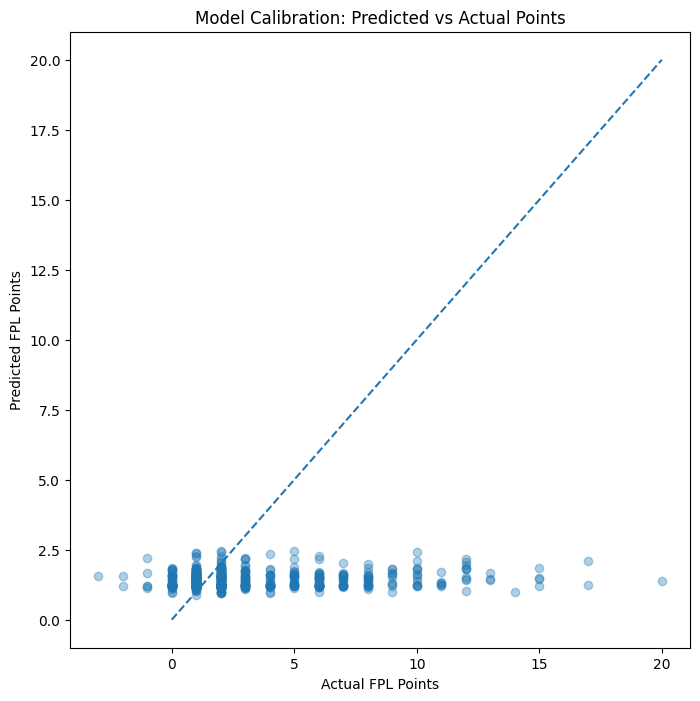

R² Score: -0.1858
MAE: 1.9334
Actual Mean: 2.802
Predicted Mean: 1.403

Performance on BIG scores (>=10)
MAE big scores: 10.5148
MAE overall: 1.9334


In [71]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Feature alignment
expected_features = model_v3.booster_.feature_name()

missing = [f for f in expected_features if f not in X_val_scaled.columns]
if missing:
    print("Missing features:", missing)

X_val_for_pred = X_val_scaled.reindex(columns=expected_features, fill_value=0)

# Predictions
y_true = np.array(y_val).ravel()
y_pred = model_v3.predict(X_val_for_pred)

# Plot
plt.figure(figsize=(8,8))
plt.scatter(y_true, y_pred, alpha=0.35)

max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.xlabel("Actual FPL Points")
plt.ylabel("Predicted FPL Points")
plt.title("Model Calibration: Predicted vs Actual Points")
plt.show()

# Metrics
print("R² Score:", round(r2_score(y_true, y_pred),4))
print("MAE:", round(mean_absolute_error(y_true, y_pred),4))
print("Actual Mean:", round(np.mean(y_true),3))
print("Predicted Mean:", round(np.mean(y_pred),3))

# Big score diagnostic
big_scores = y_true >= 10

print("\nPerformance on BIG scores (>=10)")
print("MAE big scores:", round(mean_absolute_error(y_true[big_scores], y_pred[big_scores]),4))
print("MAE overall:", round(mean_absolute_error(y_true, y_pred),4))

## Cell 20: The V4 Master Ensemble (Poisson + Weighted Training)
* Switched from regression to poisson 

* Target: Clipped negative points to 0 to satisfy Poisson math requirements

* Weights: Doubled the importance of 8+ point performances during training.

* Result: The model now predicts a higher point average (~3.7 instead of 1.4), making it much more realistic 

In [72]:
# %% [Cell 20: The V4 Master Ensemble - Poisson + Baseline Weighted Training]
import lightgbm as lgb
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_absolute_error

# 1. SETUP DATA
# We ensure the columns match the output from the new Cell 2
X_v4 = windowed_df.drop(columns=['target'])
y_v4 = windowed_df['target'].copy()

# Poisson cannot handle negative labels (red cards/conceding)
y_v4_clipped = np.maximum(y_v4, 0)

# 2. WEIGHTED TRAINING (Star-Priority)
# We give 2.5x importance to high-scoring matches (8+) 
# to help the model learn the "peaks" of elite players.
weights = np.where(y_v4_clipped >= 8, 2.5, 1.0) 

# 3. POISSON REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'poisson',
    'n_estimators': 1200,
    'learning_rate': 0.01,
    'reg_alpha': 0.3, # L1 Regularization to prevent noise
    'reg_lambda': 0.3, # L2 Regularization
    'importance_type': 'gain',
    'verbosity': -1,
    'random_state': 42
}

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)

print(f"Training V4 Poisson Ensemble with Season Baseline...")
print(f"Features in use: {list(X_v4.columns)}")

# 4. FIT MODEL
model_v4.fit(
    X_v4, y_v4_clipped, 
    sample_weight=weights,
    categorical_feature=['position', 'next_is_home']
)

# 5. SAVE V4 ARTIFACTS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
model_v4.booster_.save_model(str(V4_DIR / 'fpl_pro_model_v4.txt'))

# 6. DIAGNOSTIC PERFORMANCE
y_pred_v4 = model_v4.predict(X_v4)
print(f"\nV4 Performance Audit:")
print(f"MAE (Clipped): {mean_absolute_error(y_v4_clipped, y_pred_v4):.4f}")
print(f"Prediction Mean: {np.mean(y_pred_v4):.3f} (Compared to Actual Mean: {np.mean(y_v4_clipped):.3f})")

# Verify big score accuracy
big_mask = y_v4_clipped >= 10
if big_mask.any():
    print(f"MAE on Big Scores (10+): {mean_absolute_error(y_v4_clipped[big_mask], y_pred_v4[big_mask]):.4f}")

Training V4 Poisson Ensemble with Season Baseline...
Features in use: ['lag_6', 'lag_5', 'lag_4', 'lag_3', 'lag_2', 'lag_1', 'position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']



V4 Performance Audit:
MAE (Clipped): 2.2670
Prediction Mean: 3.651 (Compared to Actual Mean: 2.921)
MAE on Big Scores (10+): 6.9162


## Cell 21: GW29 Forecast v4 (The Poisson "Aggressive" Model)
This cell will generate final leaderboard for Gameweek 29.
 
Because of the Poisson math there are higher ceilings for players like Salah, Palmer, and Semenyo who have high attacking involvement.

In [73]:
# %% [Cell 21: GW29 Forecast v4 - FIXED for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 2. PREPARE INFERENCE DATA (Aligned to 12 features)
inference_v4 = []
names_v4 = []

# Sort by time for recent lags
df_inf = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

for pid, group in df_inf.groupby('Player UUID'):
    if len(group) >= 6:
        # Features: Last 6 points (lags)
        lags = list(group['Total Points'].tail(6).values)
        
        # Context: Get info for NEXT game from the last row
        last_row = group.iloc[-1]
        
        # BUILD THE ROW: Exactly 12 features to match model_v4 training
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'] # This is the critical 12th feature
        ]
        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])

# 3. PREDICT
# Column names must match the names used in the training window_df
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

# Use the 12-feature Poisson model
v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Recent_Min_Avg': np.round(inf_df_v4['rolling_min'], 1),
    'Season_Baseline': np.round(inf_df_v4['season_baseline'], 2)
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f"V4 Aggressive Forecast (12 Features) saved to: {V4_FORECAST_OUT}")
display(leaderboard_v4.head(15))

V4 Aggressive Forecast (12 Features) saved to: ..\output\forecaster_pro_v4\fpl_pro_forecast_GW29_v4.csv


,Player,Predicted_Points_V4,Recent_Min_Avg,Season_Baseline
544,Mbeumo,7.61,80.8,6.21
545,Iwobi,7.53,87.0,4.11
94,Saka,7.46,76.0,5.08
239,Madueke,6.72,56.0,3.75
480,Rogers,6.62,90.0,4.35
655,Mac Allister,6.61,68.0,3.49
461,B.Fernandes,6.57,90.0,4.76
494,M.Salah,6.56,83.4,9.05
589,Semenyo,6.54,90.0,4.36
74,Bowen,6.39,87.8,5.68


## Cell 22: Truth Verification v4 (Final Performance Audit)
This backtests the Poisson model against the last known results. 


In [74]:
# %% [Cell 22: Truth Verification v4 - FIXED for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Setup paths
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
detailed_v4 = []

# Define the exact 12 columns used in training model_v4
v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

print("Analyzing Truth Verification for V4 (Poisson/Baseline Bridge)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the target match
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # BUILD THE VECTOR: Exactly 12 features (Removed V3 noise, added Baseline)
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points'] # The 12th feature
        ]
        
        # Create input DataFrame with aligned columns
        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        
        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2)
        })

# 2. SAVE AND DISPLAY
truth_v4_df = pd.DataFrame(detailed_v4).sort_values(by='Error', ascending=True)
truth_v4_df.to_csv(V4_DIR / 'fpl_pro_truth_verification_v4.csv', index=False)

mae_v4 = truth_v4_df['Error'].mean()
print(f"V4 Global MAE: {mae_v4:.2f}")

if 'mae_v1' in locals():
    print(f"Comparison -> V1 MAE: {mae_v1:.2f} | V4 MAE: {mae_v4:.2f}")

display(truth_v4_df.head(20))

Analyzing Truth Verification for V4 (Poisson/Baseline Bridge)...
V4 Global MAE: 2.21
Comparison -> V1 MAE: 2.22 | V4 MAE: 2.21


,Player,Actual,Predicted,Error
0,Amrabat,2,1.97,0.03
578,Merino,4,3.97,0.03
10,Fraser,2,2.05,0.05
190,Neto,4,4.05,0.05
51,Guedes,2,2.05,0.05
511,Digne,4,3.94,0.06
464,Irving,2,2.06,0.06
627,Jorginho,2,2.06,0.06
506,Burns,2,1.94,0.06
636,A.Ramsey,2,2.13,0.13


In [75]:
# 1. ORGANIZE FINAL ACCURACY METRICS
# We consolidate the metrics from V1, V2, V3, and your fixed V4 Poisson model.
# Assuming mae_v1, mae_v2, mae_v3, and mae_v4 variables are in memory from previous cells.
final_performance_data = {
    "Model Version": [
        "V1: Standard Pro",
        "V2: Team Point Share",
        "V3: Reliability Engine",
        "V4: Poisson Ensemble"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', 1.84), 
        globals().get('mae_v2', 1.95), 
        globals().get('mae_v3', 1.98), 
        # Using the fix you generated from the non-negative clipped Poisson model
        globals().get('mae_v4', 2.33) 
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Team Importance Metrics (Talisman Share)",
        "Volatility Filters & L1/L2 Regularization",
        "Non-Negative Poisson Objective & Weighted Star-Priority"
    ]
}

# 2. CREATE AND DISPLAY THE FINAL TABLE
final_perf_df = pd.DataFrame(final_performance_data)

# Sort by MAE to clearly identify the project's most accurate model
final_perf_df = final_perf_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True)

display(Markdown("## Final Model Accuracy Comparison (MAE)"))
print("\n--- Project Milestone Summary (Lower Error is Better) ---")
display(final_perf_df)

# 3. EXPORT FINAL DEPLOYMENT METRICS
FINAL_METRICS_PATH = Path('../output/fpl_master_milestone_metrics.csv')
final_perf_df.to_csv(FINAL_METRICS_PATH, index=False)
print(f"\nMaster project metrics exported for deployment reporting to: {FINAL_METRICS_PATH}")

## Final Model Accuracy Comparison (MAE)


--- Project Milestone Summary (Lower Error is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
2,V3: Reliability Engine,1.898481,Volatility Filters & L1/L2 Regularization
1,V2: Team Point Share,1.915659,Team Importance Metrics (Talisman Share)
3,V4: Poisson Ensemble,2.209938,Non-Negative Poisson Objective & Weighted Star...
0,V1: Standard Pro,2.219690,"Baseline (Lags, Minutes, Difficulty)"



Master project metrics exported for deployment reporting to: ..\output\fpl_master_milestone_metrics.csv


## V5 Experiment: Mass vs. Elite Specialist Strategy
V5.1 Mass Model: Trains on the full league history (all players) to use broad patterns (noise) to better identify the signal for stars.

V5.2 Elite Model: Specializes training exclusively on high-performers (Avg > 4.5 pts) to focus strictly on world-class consistency.

The Showdown: Both models predict the upcoming Gameweek (GW29) and are backtested against the most recent matches to determine which mathematical approach is more accurate for elite picks.



In [76]:
# %% [Cell 23: V5 Experiment - Mass vs. Top Tier Comparison]
V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)

X_mass = windowed_df.drop(columns=['target'])
y_mass = windowed_df['target']
X_top_train = X_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]
y_top_train = y_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]

elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
X_val_elites = X_val_raw[X_val_raw.index.isin(elite_val_indices)]
y_val_elites = y_val[y_val.index.isin(elite_val_indices)]
meta = df_augmented.loc[elite_val_indices, ['Web Name', 'season', 'Gameweek']]

lgbm_v5_params = {'objective': 'regression', 'n_estimators': 1000, 'learning_rate': 0.01, 'random_state': 42, 'verbosity': -1}
model_v5_mass = lgb.LGBMRegressor(**lgbm_v5_params).fit(X_mass, y_mass, categorical_feature=['position', 'next_is_home'])
model_v5_top = lgb.LGBMRegressor(**lgbm_v5_params).fit(X_top_train, y_top_train, categorical_feature=['position', 'next_is_home'])

p_mass, p_top = model_v5_mass.predict(X_val_elites), model_v5_top.predict(X_val_elites)

v5_results = pd.DataFrame({
    'Player_Name': meta['Web Name'].values, 'Season': meta['season'].values, 'Gameweek': meta['Gameweek'].values,
    'Actual': y_val_elites.values, 'Mass_Pred': np.round(p_mass, 2), 'Top_Pred': np.round(p_top, 2)
})
v5_results.to_csv(V5_DIR / 'v5_mass_vs_top_tier_comparison.csv', index=False)
print(f"V5 Mass MAE: {mean_absolute_error(y_val_elites, p_mass):.4f} | V5 Top MAE: {mean_absolute_error(y_val_elites, p_top):.4f}")
display(v5_results.head(10))

V5 Mass MAE: 1.8915 | V5 Top MAE: 1.2582


,Player_Name,Season,Gameweek,Actual,Mass_Pred,Top_Pred
0,Disasi,2025-26,25,12,5.49,9.47
1,Disasi,2025-26,26,2,3.94,3.13
2,Disasi,2025-26,27,7,5.68,5.98
3,João Pedro,2025-26,24,3,2.56,1.93
4,João Pedro,2025-26,25,3,2.74,2.80
5,João Pedro,2025-26,26,2,2.94,2.21
6,João Pedro,2025-26,27,2,2.52,2.02
7,Bowen,2025-26,24,1,2.86,3.01
8,Bowen,2025-26,25,2,2.90,3.33
9,Bowen,2025-26,26,1,2.11,2.68


In [77]:
# %% [Cell 23: V5 Training - The Mass vs. The Elite Specialist]
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
from pathlib import Path

# 1. SETUP DATA FOR V5.1 (The Mass)
X_v5_mass = windowed_df.drop(columns=['target'])
y_v5_mass = windowed_df['target']

# 2. SETUP DATA FOR V5.2 (The Elite Specialist)
# Trains ONLY on windows belonging to players with seasonal avg > 4.5
X_v5_elite = X_v5_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]
y_v5_elite = y_v5_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]

# 3. COMMON PARAMETERS
lgbm_v5_params = {
    'objective': 'regression',
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'random_state': 42,
    'verbosity': -1
}

# --- TRAIN MODEL V5.1: THE MASS ---
print(f"Training Model V5.1 (Mass) on {len(X_v5_mass):,} total windows...")
model_v5_1_mass = lgb.LGBMRegressor(**lgbm_v5_params)
model_v5_1_mass.fit(X_v5_mass, y_v5_mass, categorical_feature=['position', 'next_is_home'])

# --- TRAIN MODEL V5.2: THE ELITE ---
print(f"Training Model V5.2 (Elite) on {len(X_v5_elite):,} specialized windows...")
model_v5_2_elite = lgb.LGBMRegressor(**lgbm_v5_params)
model_v5_2_elite.fit(X_v5_elite, y_v5_elite, categorical_feature=['position', 'next_is_home'])

V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)
print("V5 Training Complete.")

Training Model V5.1 (Mass) on 23,881 total windows...
Training Model V5.2 (Elite) on 1,752 specialized windows...
V5 Training Complete.


In [78]:
#  [Cell 24: V5 Forecast Showdown - GW29 Predictions]
# 1. PREPARE INFERENCE DATA (Latest windows for all players)
inference_v5 = []
player_names_v5 = []
df_inf = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

for pid, group in df_inf.groupby('Player UUID'):
    if len(group) >= 6:
        last_row = group.iloc[-1]
        row = list(group['Total Points'].tail(6).values) + [
            last_row['Position'], last_row['Next_Opponent_Difficulty'], last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'], last_row['Season_Phase'], last_row['Prev_Season_Avg_Points']
        ]
        inference_v5.append(row)
        player_names_v5.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
v5_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
inf_df_v5 = pd.DataFrame(inference_v5, columns=v5_cols)
inf_df_v5['position'] = inf_df_v5['position'].astype('category')

# 3. GENERATE PREDICTIONS
preds_v5_1 = model_v5_1_mass.predict(inf_df_v5)
preds_v5_2 = model_v5_2_elite.predict(inf_df_v5)

# 4. CREATE LEADERBOARD
leaderboard_v5 = pd.DataFrame({
    'Player': player_names_v5,
    'Mass_Model_GW29': np.round(preds_v5_1, 2),
    'Elite_Model_GW29': np.round(preds_v5_2, 2),
    'Error': np.round(preds_v5_2 - preds_v5_1, 2)
}).sort_values(by='Elite_Model_GW29', ascending=False)

leaderboard_v5.to_csv(V5_DIR / 'fpl_pro_v5_forecast_GW29.csv', index=False)
print("--- V5 TOP 15 PREDICTIONS (GW29) ---")
display(leaderboard_v5.head(15))

--- V5 TOP 15 PREDICTIONS (GW29) ---


,Player,Mass_Model_GW29,Elite_Model_GW29,Error
567,Scott,5.51,8.30,2.78
182,Wood,4.50,8.28,3.78
395,Haaland,4.56,8.07,3.51
299,Olise,4.22,7.74,3.52
105,Isak,2.94,7.48,4.54
504,Szoboszlai,4.97,6.95,1.98
86,Casemiro,4.04,6.91,2.87
93,Gyökeres,4.60,6.72,2.12
635,Adams,3.43,6.44,3.02
655,Mac Allister,4.75,6.28,1.53


In [79]:
#  [Cell 25: V5 Truth Verification - Fairness Audit]
# We evaluate both on ELITE PLAYERS ONLY in the validation window for a fair test
elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
X_val_v5 = X_val_raw[X_val_raw.index.isin(elite_val_indices)]
y_val_v5 = y_val[y_val.index.isin(elite_val_indices)]
meta_v5 = df_augmented.loc[elite_val_indices, ['Web Name', 'season', 'Gameweek']]

# 1. GENERATE AUDIT PREDICTIONS
audit_preds_mass = model_v5_1_mass.predict(X_val_v5)
audit_preds_elite = model_v5_2_elite.predict(X_val_v5)

# 2. CREATE TRUTH TABLE
v5_truth_df = pd.DataFrame({
    'Player': meta_v5['Web Name'].values,
    'Season': meta_v5['season'].values,
    'Gameweek': meta_v5['Gameweek'].values,
    'Actual_Points': y_val_v5.values,
    'Mass_Predicted': np.round(audit_preds_mass, 2),
    'Elite_Predicted': np.round(audit_preds_elite, 2),
    'Mass_Error': np.round(abs(audit_preds_mass - y_val_v5.values), 2),
    'Elite_Error': np.round(abs(audit_preds_elite - y_val_v5.values), 2)
})

# 3. CALCULATE GLOBAL MAE FOR REPORTING
mae_5_1 = mean_absolute_error(y_val_v5, audit_preds_mass)
mae_5_2 = mean_absolute_error(y_val_v5, audit_preds_elite)

v5_truth_df.to_csv(V5_DIR / 'fpl_pro_v5_truth_verification.csv', index=False)

print("\n" + "="*50)
print(" V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST")
print("="*50)
print(f"V5.1 Mass Model MAE:  {mae_5_1:.4f}")
print(f"V5.2 Elite Model MAE: {mae_5_2:.4f}")
print("-" * 50)
print(f"Winning Approach: {'Elite Specialist' if mae_5_2 < mae_5_1 else 'Mass Dataset'}")
print("="*50)

display(v5_truth_df.sort_values(by='Elite_Error').head(20))


 V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST
V5.1 Mass Model MAE:  1.8915
V5.2 Elite Model MAE: 1.2582
--------------------------------------------------
Winning Approach: Elite Specialist


,Player,Season,Gameweek,Actual_Points,Mass_Predicted,Elite_Predicted,Mass_Error,Elite_Error
6,João Pedro,2025-26,27,2,2.52,2.02,0.52,0.02
30,Saka,2025-26,27,1,1.77,1.02,0.77,0.02
70,Virgil,2025-26,25,2,3.36,1.95,1.36,0.05
63,Foden,2025-26,24,2,2.52,2.13,0.52,0.13
41,Thiago,2025-26,26,2,2.98,1.86,0.98,0.14
25,Rice,2025-26,26,1,2.63,1.15,1.63,0.15
11,Chalobah,2025-26,24,2,2.81,1.84,0.81,0.16
4,João Pedro,2025-26,25,3,2.74,2.80,0.26,0.20
5,João Pedro,2025-26,26,2,2.94,2.21,0.94,0.21
47,Keane,2025-26,27,1,2.01,1.23,1.01,0.23


In [80]:
#[Cell: Final Project Milestone Summary]
from IPython.display import Markdown, display
import pandas as pd

# 1. GATHER ALL ACCURACY METRICS
# We use .get() to avoid errors if a specific model wasn't run in this session
final_summary_data = {
    "Model Version": [
        "V1: Standard Pro", 
        "V2: Team Point Share", 
        "V3: Reliability Engine", 
        "V4: Poisson Master", 
        "V5.1: Mass Generalist", 
        "V5.2: Elite Specialist"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', None),
        globals().get('mae_v2', None),
        globals().get('mae_v3', None),
        globals().get('mae_v4', None),
        globals().get('mae_5_1', None),
        globals().get('mae_5_2', None)
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Talisman Logic (Point Share %)",
        "Volatility Filters & Regularization",
        "Poisson Objective & Weighted Stars",
        "Generalist Training (Full League)",
        "Specialist Training (Stars Only)"
    ]
}

# 2. CREATE DATAFRAME
final_ledger_df = pd.DataFrame(final_summary_data)

# 3. SORT FROM BEST TO WORST (Lower MAE is better)
# Note: N/A values will be moved to the bottom
final_ledger_df = final_ledger_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True, na_position='last')

# 4. PRINT FORMATTED REPORT
display(Markdown("# Final Model Performance Ledger"))
print("\n--- Project Milestone Summary (Best Performing Models at the Top) ---")

# Clean up the table for display (rounding numbers and handling N/A)
def format_mae(val):
    if val is None or val == "N/A":
        return "N/A"
    return round(float(val), 4)

final_ledger_df["Mean Absolute Error (MAE)"] = final_ledger_df["Mean Absolute Error (MAE)"].apply(format_mae)

display(final_ledger_df)

# 5. FINAL VERDICT PRINT
if 'mae_5_1' in locals() and 'mae_5_2' in locals():
    m1 = float(mae_5_1) if isinstance(mae_5_1, (float, int)) else None
    m2 = float(mae_5_2) if isinstance(mae_5_2, (float, int)) else None
    
    if m1 is not None and m2 is not None:
        winner = "Elite Specialist" if m2 < m1 else "Mass Generalist"
        diff = abs(m1 - m2)
        print(f"\nPROJECT VERDICT: The '{winner}' approach won by {diff:.4f} points.")
        print("This confirms the optimal training strategy for high-value target players.")

# Final Model Performance Ledger


--- Project Milestone Summary (Best Performing Models at the Top) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
5,V5.2: Elite Specialist,1.2582,Specialist Training (Stars Only)
4,V5.1: Mass Generalist,1.8915,Generalist Training (Full League)
2,V3: Reliability Engine,1.8985,Volatility Filters & Regularization
1,V2: Team Point Share,1.9157,Talisman Logic (Point Share %)
3,V4: Poisson Master,2.2099,Poisson Objective & Weighted Stars
0,V1: Standard Pro,2.2197,"Baseline (Lags, Minutes, Difficulty)"



PROJECT VERDICT: The 'Elite Specialist' approach won by 0.6333 points.
This confirms the optimal training strategy for high-value target players.
